<a href="https://colab.research.google.com/github/AdityaMall1093/ML-Learning/blob/main/Cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train: (12616, 785)
Test : (13212, 784)
X_train: (10092, 28, 28, 1)
X_val  : (2524, 28, 28, 1)
X_test : (13212, 28, 28, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.7835 - loss: 0.6672 - val_accuracy: 0.9505 - val_loss: nan
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.9417 - loss: 0.2049 - val_accuracy: 0.9584 - val_loss: nan
Epoch 3/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.9534 - loss: 0.1479 - val_accuracy: 0.9723 - val_loss: nan
Epoch 4/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9621 - loss: 0.1166 - val_accuracy: 0.9727 - val_loss: nan
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9505 - loss: nan
Validation Accuracy: 0.9504754543304443
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       247
           1       0.97      0.96      0.96       284
           2       0.91      0.95      0.93       259
           3       0.96      0.95      0.95       255
           4       0.93      0.98      0.95       244
           5    

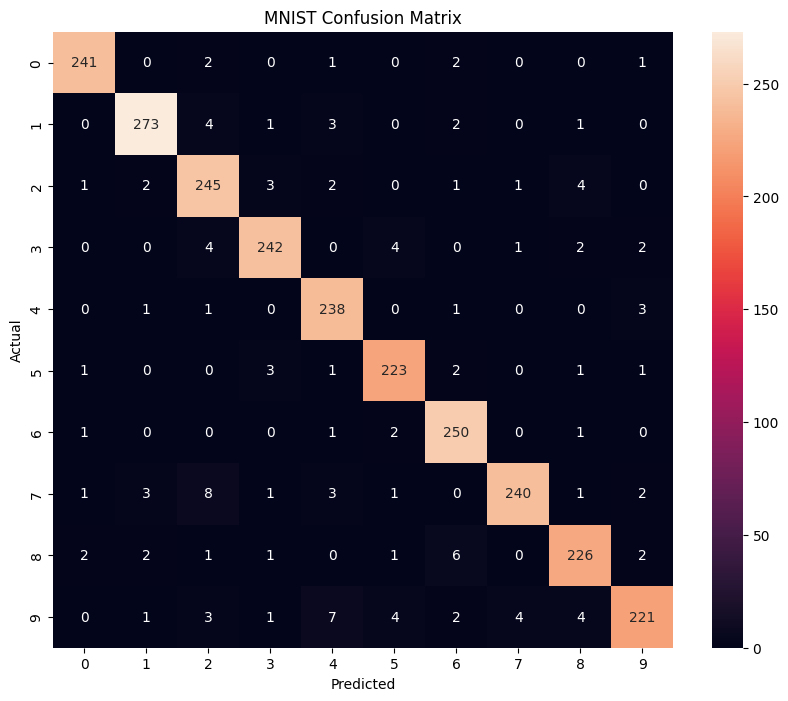

In [4]:
# ==============================
# 1. Imports
# ==============================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping


# ==============================
# 2. Load data
# ==============================

df = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

print("Train:", df.shape)
print("Test :", df_test.shape)


# ==============================
# 3. Separate X and y
# ==============================

X = df.drop("label", axis=1).values
y = df["label"].values

X_test = df_test.values


# ==============================
# 4. Normalize
# ==============================

X = X.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


# ==============================
# 5. Train / Validation split
# ==============================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==============================
# 6. Reshape for CNN
# ==============================

X_train = X_train.reshape(-1, 28, 28, 1)
X_val = X_val.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)


# ==============================
# 7. CNN Model
# ==============================

model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(10, activation="softmax")
])


# ==============================
# 8. Compile
# ==============================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ==============================
# 9. Early stopping
# ==============================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


# ==============================
# 10. Train
# ==============================

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop]
)


# ==============================
# 11. Evaluate
# ==============================

loss, accuracy = model.evaluate(X_val, y_val)

print("Validation Accuracy:", accuracy)


# ==============================
# 12. Predictions
# ==============================

y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)


# ==============================
# 13. Classification report
# ==============================

print(classification_report(y_val, y_pred))


# ==============================
# 14. Confusion matrix
# ==============================

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MNIST Confusion Matrix")
plt.show()